# KIARA — Model Comparison
### Knowledge-based Intelligent Analysis for Retinal Assessment

## Objective

This notebook performs a rigorous, apples-to-apples comparison of four
deep learning architectures for **Diabetic Retinopathy (DR) severity
classification** on the APTOS 2019 dataset:

1. **MaxViT (MaxViT-Tiny)** (PyTorch, `timm`) — a hybrid CNN-transformer
   architecture combining MBConv blocks with block and grid attention,
   capturing both local texture detail and long-range spatial dependencies.
2. **Vision Transformer (ViT-Base/16)** (PyTorch, `timm`) — a pure
   self-attention architecture that treats an image as a sequence of patches.
3. **Swin Transformer (Swin-Base)** (PyTorch, `timm`) — a hierarchical
   transformer using shifted windows, combining transformer expressiveness
   with CNN-like locality and multi-scale feature maps.
4. **DINOv2 (ViT-Base, self-supervised)** (PyTorch, `timm`) — a self-supervised
   vision transformer trained via distillation on unlabeled images, then
   fine-tuned here for DR classification, testing whether self-supervised
   pretraining yields better retinal features than supervised ImageNet weights.

## Why Model Comparison Matters

DR severity grading is an ordinal, clinically high-stakes task: a
misclassification between adjacent severity grades has very different
consequences than one between distant grades (e.g., "No DR" mistaken for
"Proliferative DR"). Comparing architecturally distinct model families
under **identical preprocessing, identical test data, and identical
metrics** is the only way to draw a fair conclusion about which inductive
biases — convolutional locality, global self-attention, hierarchical
windowed attention, or hybrid CNN-transformer design — best suit retinal
fundus imagery.

## Fairness Guarantee

All four models below are evaluated on **the exact same held-out test
set**, resized to the exact same resolution, with no test-time
augmentation for any model. All four are PyTorch/`timm` models sharing the
same ImageNet-normalization preprocessing pipeline and the same
`APTOSTestDataset` / `DataLoader`.

In [25]:
# Import Libraries

# ------------------------------------------------------------------
# Standard library
# ------------------------------------------------------------------
import os
import warnings

# ------------------------------------------------------------------
# Numerical / data handling
# ------------------------------------------------------------------
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# PyTorch (MaxViT, ViT, Swin, DINOv2)
# ------------------------------------------------------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

# ------------------------------------------------------------------
# Image handling
# ------------------------------------------------------------------
from PIL import Image

# ------------------------------------------------------------------
# Metrics
# ------------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
)

# ------------------------------------------------------------------
# Progress bars
# ------------------------------------------------------------------
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [26]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    for file in files:
        if file.endswith((".keras", ".pth")):
            print(os.path.join(root, file))

/kaggle/input/datasets/pawanmanghnani/swin-kiara/best_swin_model.pth
/kaggle/input/datasets/pawanmanghnani/vit-kiara/best_vit_model.pth
/kaggle/input/datasets/pawanmanghnani/resnet50-kiara/kiara_resnet50_best-2.keras
/kaggle/input/datasets/pawanmanghnani/maxvit-kiara/best_maxvit_model.pth
/kaggle/input/datasets/pawanmanghnani/dino-kiara/best_dino_model.pth


In [37]:
## Section 3 — Dataset Configuration

# ------------------------------------------------------------------
# Dataset paths (APTOS 2019 — mariaherrerot/aptos2019 Kaggle layout)
# ------------------------------------------------------------------
DATA_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

# Some dataset mirrors nest images one directory deeper
# (e.g. test_images/test_images/*.png). Resolve automatically.
def resolve_image_dir(base_dir: str, folder_name: str) -> str:
    """Return the directory that actually contains the .png files,
    handling both flat and doubly-nested folder layouts."""
    flat_path = os.path.join(base_dir, folder_name)
    nested_path = os.path.join(base_dir, folder_name, folder_name)
    if os.path.isdir(nested_path) and len(os.listdir(nested_path)) > 0:
        return nested_path
    return flat_path

TEST_IMG_DIR = resolve_image_dir(DATA_DIR, "test_images")

# ------------------------------------------------------------------
# Model checkpoint paths (attach these as a Kaggle dataset/output)
# ------------------------------------------------------------------
MAXVIT_MODEL_PATH = "/kaggle/input/datasets/pawanmanghnani/maxvit-kiara/best_maxvit_model.pth"

VIT_MODEL_PATH = "/kaggle/input/datasets/pawanmanghnani/vit-kiara/best_vit_model.pth"

SWIN_MODEL_PATH = "/kaggle/input/datasets/pawanmanghnani/swin-kiara/best_swin_model.pth"

DINOV2_MODEL_PATH = "/kaggle/input/datasets/pawanmanghnani/dino-kiara/best_dino_model.pth"
# ------------------------------------------------------------------
# Image / batching configuration
# ------------------------------------------------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

CLASS_NAMES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [39]:
import os

print(os.listdir("/kaggle/input/datasets"))

['pawanmanghnani', 'mariaherrerot']


In [40]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    for f in files:
        if f.endswith((".keras", ".pth")):
            print(os.path.join(root, f))

/kaggle/input/datasets/pawanmanghnani/swin-kiara/best_swin_model.pth
/kaggle/input/datasets/pawanmanghnani/vit-kiara/best_vit_model.pth
/kaggle/input/datasets/pawanmanghnani/resnet50-kiara/kiara_resnet50_best-2.keras
/kaggle/input/datasets/pawanmanghnani/maxvit-kiara/best_maxvit_model.pth
/kaggle/input/datasets/pawanmanghnani/dino-kiara/best_dino_model.pth


In [41]:
## Section 4 — Load MaxViT (PyTorch, `timm`)
maxvit_model = timm.create_model(
    "maxvit_tiny_tf_224",
    pretrained=False,
    num_classes=NUM_CLASSES,
)

maxvit_state_dict = torch.load(MAXVIT_MODEL_PATH, map_location=device)
maxvit_model.load_state_dict(maxvit_state_dict)

maxvit_model = maxvit_model.to(device)
maxvit_model.eval()

print(f"Loaded MaxViT from: {MAXVIT_MODEL_PATH}")
maxvit_total_params = sum(p.numel() for p in maxvit_model.parameters())
print(f"Total parameters: {maxvit_total_params:,}")


Loaded MaxViT from: /kaggle/input/datasets/pawanmanghnani/maxvit-kiara/best_maxvit_model.pth
Total parameters: 30,406,093


In [42]:
## Section 5 — Load Vision Transformer (PyTorch, `timm`)
vit_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=NUM_CLASSES,
)

vit_state_dict = torch.load(VIT_MODEL_PATH, map_location=device)
vit_model.load_state_dict(vit_state_dict)

vit_model = vit_model.to(device)
vit_model.eval()

print(f"Loaded Vision Transformer from: {VIT_MODEL_PATH}")
vit_total_params = sum(p.numel() for p in vit_model.parameters())
print(f"Total parameters: {vit_total_params:,}")


Loaded Vision Transformer from: /kaggle/input/datasets/pawanmanghnani/vit-kiara/best_vit_model.pth
Total parameters: 85,802,501


In [43]:
checkpoint = torch.load(DINOV2_MODEL_PATH, map_location="cpu")

print(type(checkpoint))
print(list(checkpoint.keys())[:20])

<class 'collections.OrderedDict'>
['cls_token', 'pos_embed', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.qkv.bias', 'blocks.0.attn.proj.weight', 'blocks.0.attn.proj.bias', 'blocks.0.ls1.gamma', 'blocks.0.norm2.weight', 'blocks.0.norm2.bias', 'blocks.0.mlp.fc1.weight', 'blocks.0.mlp.fc1.bias', 'blocks.0.mlp.fc2.weight', 'blocks.0.mlp.fc2.bias', 'blocks.0.ls2.gamma', 'blocks.1.norm1.weight', 'blocks.1.norm1.bias']


In [44]:
## Section 6 — Load Swin Transformer (PyTorch, `timm`)
swin_model = timm.create_model(
    "swin_base_patch4_window7_224",
    pretrained=False,
    num_classes=NUM_CLASSES,
)

swin_state_dict = torch.load(SWIN_MODEL_PATH, map_location=device)
swin_model.load_state_dict(swin_state_dict)

swin_model = swin_model.to(device)
swin_model.eval()

print(f"Loaded Swin Transformer from: {SWIN_MODEL_PATH}")
swin_total_params = sum(p.numel() for p in swin_model.parameters())
print(f"Total parameters: {swin_total_params:,}")


Loaded Swin Transformer from: /kaggle/input/datasets/pawanmanghnani/swin-kiara/best_swin_model.pth
Total parameters: 86,748,349


In [45]:
dinov2_model = timm.create_model(
    "vit_base_patch14_dinov2.lvd142m",
    pretrained=False,
    num_classes=5,
    img_size=224,
)

state_dict = torch.load(DINOV2_MODEL_PATH, map_location=device)
dinov2_model.load_state_dict(state_dict)

dinov2_model = dinov2_model.to(device)
dinov2_model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=Fal

## Section 7 — Create Test Dataset
# ------------------------------------------------------------------
# TensorFlow test dataset (for ResNet50)
# ------------------------------------------------------------------
def load_and_preprocess_tf(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

tf_file_paths = test_df["file_path"].values
tf_labels = test_df["diagnosis"].values.astype(np.int32)

tf_test_dataset = tf.data.Dataset.from_tensor_slices((tf_file_paths, tf_labels))
tf_test_dataset = tf_test_dataset.map(load_and_preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE)
tf_test_dataset = tf_test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"TensorFlow test dataset ready: {len(test_df)} samples, batch size {BATCH_SIZE}")


In [47]:
# ------------------------------------------------------------------
# Load APTOS test dataframe
# ------------------------------------------------------------------
test_df = pd.read_csv(TEST_CSV)

# Create full image paths
test_df["file_path"] = test_df["id_code"].apply(
    lambda x: os.path.join(TEST_IMG_DIR, f"{x}.png")
)

print(f"Test samples: {len(test_df)}")
display(test_df.head())

Test samples: 366


,id_code,diagnosis,file_path
0,e4dcca36ceb4,0,/kaggle/input/datasets/mariaherrerot/aptos2019...
1,e4e343eaae2a,2,/kaggle/input/datasets/mariaherrerot/aptos2019...
2,e4f12411fd85,4,/kaggle/input/datasets/mariaherrerot/aptos2019...
3,e50b0174690d,0,/kaggle/input/datasets/mariaherrerot/aptos2019...
4,e5197d77ec68,0,/kaggle/input/datasets/mariaherrerot/aptos2019...


In [48]:
# ------------------------------------------------------------------
# PyTorch test dataset (shared by ViT and Swin)
# ------------------------------------------------------------------
class APTOSTestDataset(Dataset):
    """Read-only test dataset shared by all PyTorch models."""

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.loc[idx]
        image = Image.open(row["file_path"]).convert("RGB")
        label = int(row["diagnosis"])

        if self.transform:
            image = self.transform(image)

        return image, label


test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

torch_test_dataset = APTOSTestDataset(test_df, transform=test_transform)
torch_test_loader = DataLoader(
    torch_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # must stay False: row order must match test_df
    num_workers=2,
    pin_memory=True,
)

print(f"PyTorch test loader ready: {len(torch_test_dataset)} samples, "
      f"{len(torch_test_loader)} batches")


PyTorch test loader ready: 366 samples, 12 batches


In [53]:
## Section 8 — Prediction Functions
def _predict_torch_model(model, loader, device):
    """Shared inference loop for any PyTorch classifier (MaxViT, ViT, Swin, ...)."""
    model.eval()

    all_true, all_pred, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting", leave=False):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_true.extend(labels.numpy())
            all_pred.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_true), np.array(all_pred), np.array(all_probs)


def predict_maxvit(model=maxvit_model, loader=torch_test_loader, device=device):
    """Run inference with the MaxViT model."""
    return _predict_torch_model(model, loader, device)


def predict_vit(model=vit_model, loader=torch_test_loader, device=device):
    """Run inference with the Vision Transformer model."""
    return _predict_torch_model(model, loader, device)


def predict_swin(model=swin_model, loader=torch_test_loader, device=device):
    """Run inference with the Swin Transformer model."""
    return _predict_torch_model(model, loader, device)


def predict_dinov2(model=dinov2_model, loader=torch_test_loader, device=device):
    """Run inference with the DINOv2 model."""
    return _predict_torch_model(model, loader, device)

In [54]:
# ------------------------------------------------------------------
# Run inference for all four models

maxvit_true, maxvit_pred, maxvit_probs = predict_maxvit()
vit_true, vit_pred, vit_probs = predict_vit()
swin_true, swin_pred, swin_probs = predict_swin()
dinov2_true, dinov2_pred, dinov2_probs = predict_dinov2()

# Sanity check
assert np.array_equal(maxvit_true, vit_true), "MaxViT and ViT label order mismatch!"
assert np.array_equal(vit_true, swin_true), "ViT and Swin label order mismatch!"
assert np.array_equal(vit_true, dinov2_true), "ViT and DINOv2 label order mismatch!"

print(f"DINOv2 predictions: {len(dinov2_pred)}")

Predicting:   0%|          | 0/12 [00:00<?, ?it/s]

Predicting:   0%|          | 0/12 [00:00<?, ?it/s]

Predicting:   0%|          | 0/12 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e5707125760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e5707125760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Predicting:   0%|          | 0/12 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e5707125760>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e5707125760>    
self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    if w.is_alive():    
self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive():
     ^ ^ ^ ^ ^^ ^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^^assert self._parent_pid == os.getpid(), 'can only test a child process'^

   File "/usr/lib/pytho

DINOv2 predictions: 366


In [55]:
## Section 9 — Evaluation Metrics
def evaluate_model(model_name: str, y_true, y_pred):
    """
    Compute the full evaluation suite for one model's predictions.

    Returns:
        dict with keys: accuracy, precision, recall, f1, balanced_accuracy,
        qwk, mcc, and confusion_matrix (np.ndarray).
    """
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "QWK": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

    cm = confusion_matrix(y_true, y_pred)

    print("=" * 60)
    print(f"EVALUATION SUMMARY — {model_name}")
    print("=" * 60)
    for key, value in metrics.items():
        if key != "Model":
            print(f"{key:<20}: {value:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(
        y_true, y_pred,
        target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
        zero_division=0,
    ))

    return metrics, cm

# Ground truth labels (same for all models)
y_true = maxvit_true

maxvit_metrics, maxvit_cm = evaluate_model("MaxViT", y_true, maxvit_pred)
vit_metrics, vit_cm = evaluate_model("Vision Transformer", y_true, vit_pred)
swin_metrics, swin_cm = evaluate_model("Swin Transformer", y_true, swin_pred)
dinov2_metrics, dinov2_cm = evaluate_model("DINOv2", y_true, dinov2_pred)

EVALUATION SUMMARY — MaxViT
Accuracy            : 0.8579
Precision           : 0.8610
Recall              : 0.8579
F1 Score            : 0.8498
Balanced Accuracy   : 0.6469
QWK                 : 0.9196
MCC                 : 0.7755

Classification Report:

                  precision    recall  f1-score   support

           No DR       0.99      0.99      0.99       199
            Mild       0.67      0.47      0.55        30
        Moderate       0.69      0.91      0.78        87
          Severe       0.50      0.29      0.37        17
Proliferative DR       0.90      0.58      0.70        33

        accuracy                           0.86       366
       macro avg       0.75      0.65      0.68       366
    weighted avg       0.86      0.86      0.85       366

EVALUATION SUMMARY — Vision Transformer
Accuracy            : 0.8497
Precision           : 0.8489
Recall              : 0.8497
F1 Score            : 0.8435
Balanced Accuracy   : 0.6476
QWK                 : 0.9224
MCC  

In [56]:
## Section 10 — Comparison Table
comparison_df = pd.DataFrame([maxvit_metrics, vit_metrics, swin_metrics, dinov2_metrics])
comparison_df = comparison_df.set_index("Model")
comparison_df = comparison_df.round(4)

metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score",
                   "Balanced Accuracy", "QWK", "MCC"]

styled_comparison = (
    comparison_df[metric_columns]
    .style
    .highlight_max(axis=0, color="lightgreen")
    .format("{:.4f}")
    .set_caption("KIARA Model Comparison — APTOS 2019 Test Set")
)

styled_comparison

,Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,QWK,MCC
Model,,,,,,,
MaxViT,0.8579,0.8610,0.8579,0.8498,0.6469,0.9196,0.7755
Vision Transformer,0.8497,0.8489,0.8497,0.8435,0.6476,0.9224,0.7605
Swin Transformer,0.8579,0.8516,0.8579,0.8510,0.6645,0.9027,0.7727
DINOv2,0.8005,0.7883,0.8005,0.7798,0.5391,0.8903,0.6775


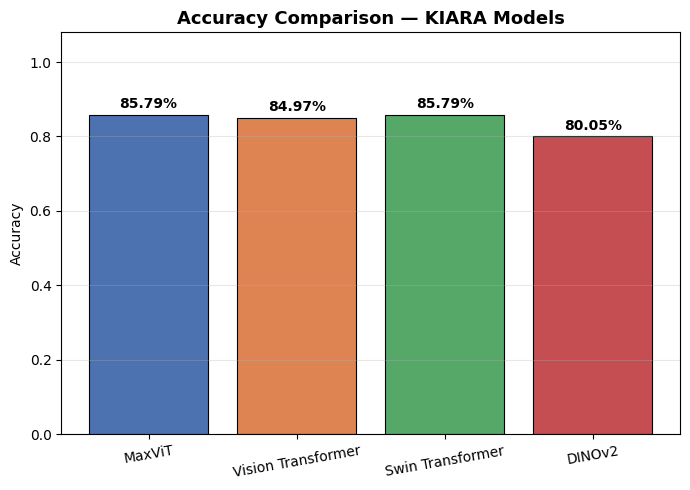

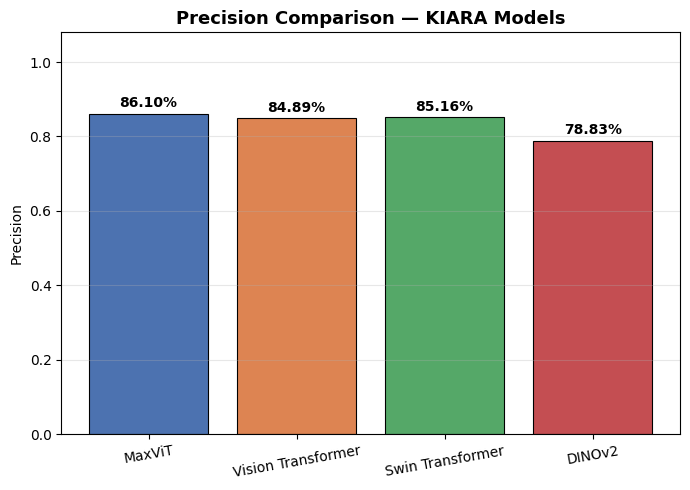

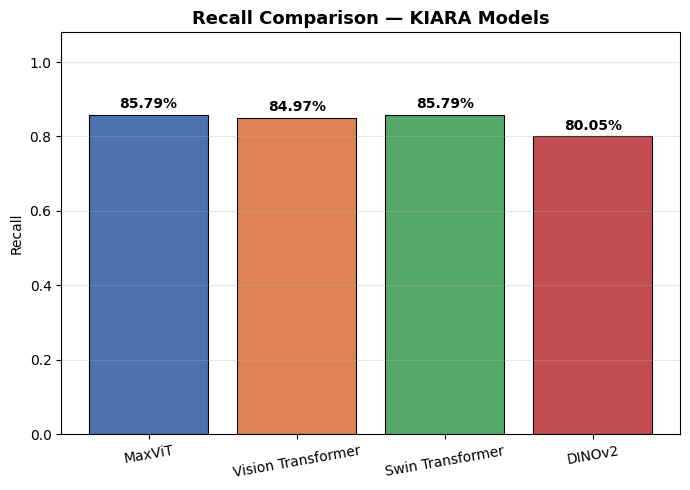

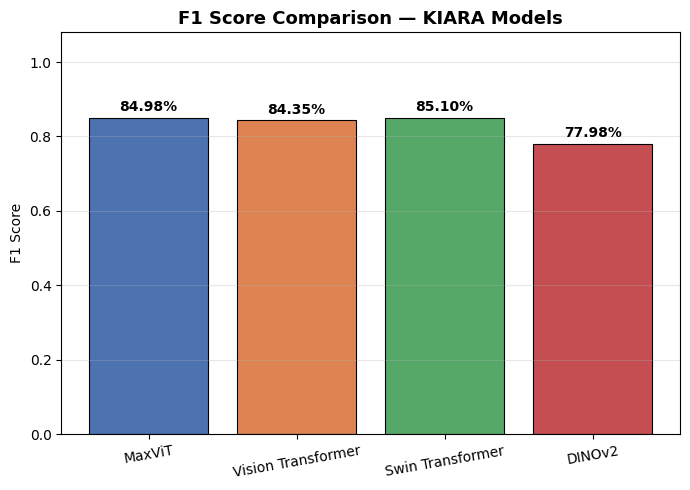

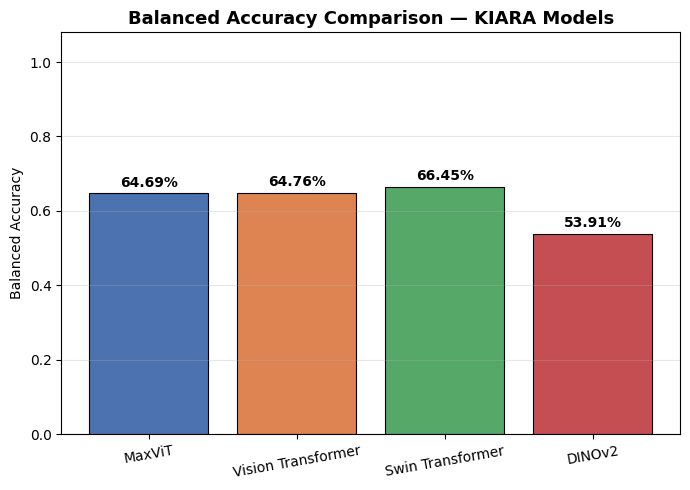

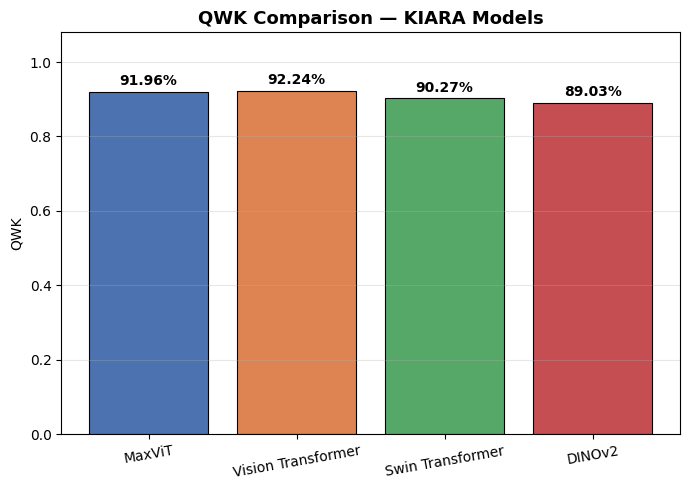

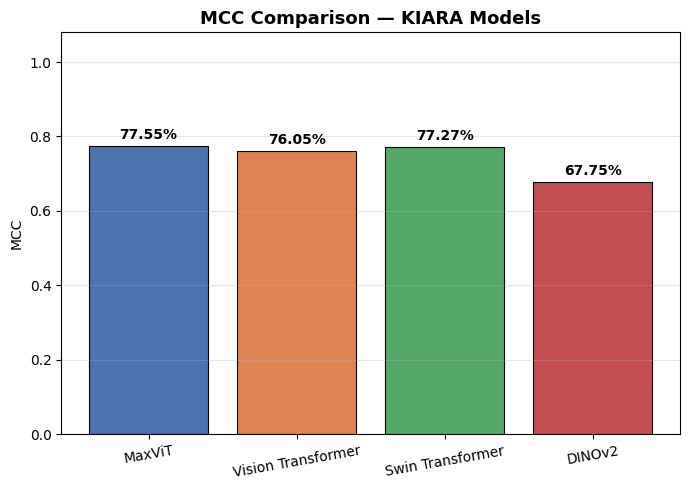

In [57]:
## Section 11 — Visualization
MODEL_COLORS = {
    "MaxViT": "#4C72B0",
    "Vision Transformer": "#DD8452",
    "Swin Transformer": "#55A868",
    "DINOv2" : "#C44E52",
}

def plot_metric_comparison(metric_name: str, comparison_df: pd.DataFrame):
    """Publication-quality bar chart comparing one metric across all models."""
    values = comparison_df[metric_name]
    colors = [MODEL_COLORS[model] for model in values.index]

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(values.index, values.values, color=colors, edgecolor="black", linewidth=0.8)

    for bar, value in zip(bars, values.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{value * 100:.2f}%",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )

    ax.set_title(f"{metric_name} Comparison — KIARA Models", fontsize=13, fontweight="bold")
    ax.set_ylabel(metric_name)
    ax.set_ylim(0, 1.08)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()


for metric in metric_columns:
    plot_metric_comparison(metric, comparison_df)

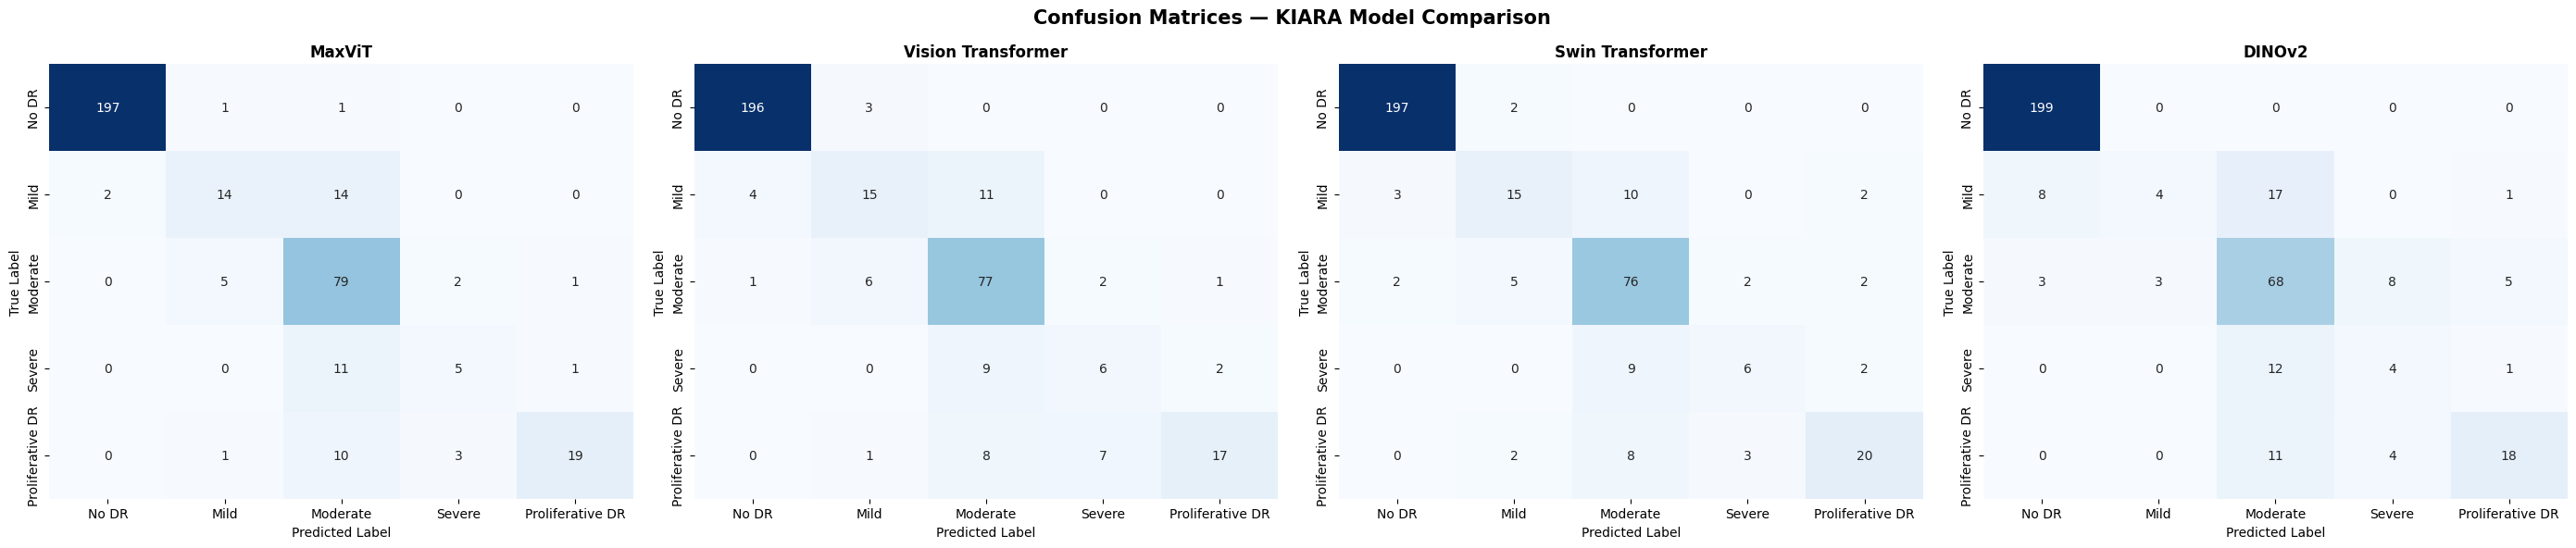

In [58]:
## Section 12 — Confusion Matrices
confusion_matrices = {
    "MaxViT": maxvit_cm,
    "Vision Transformer": vit_cm,
    "Swin Transformer": swin_cm,
    "DINOv2": dinov2_cm,
}

fig, axes = plt.subplots(1, 4, figsize=(28, 6))

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
        xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
        yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    )
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices — KIARA Model Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

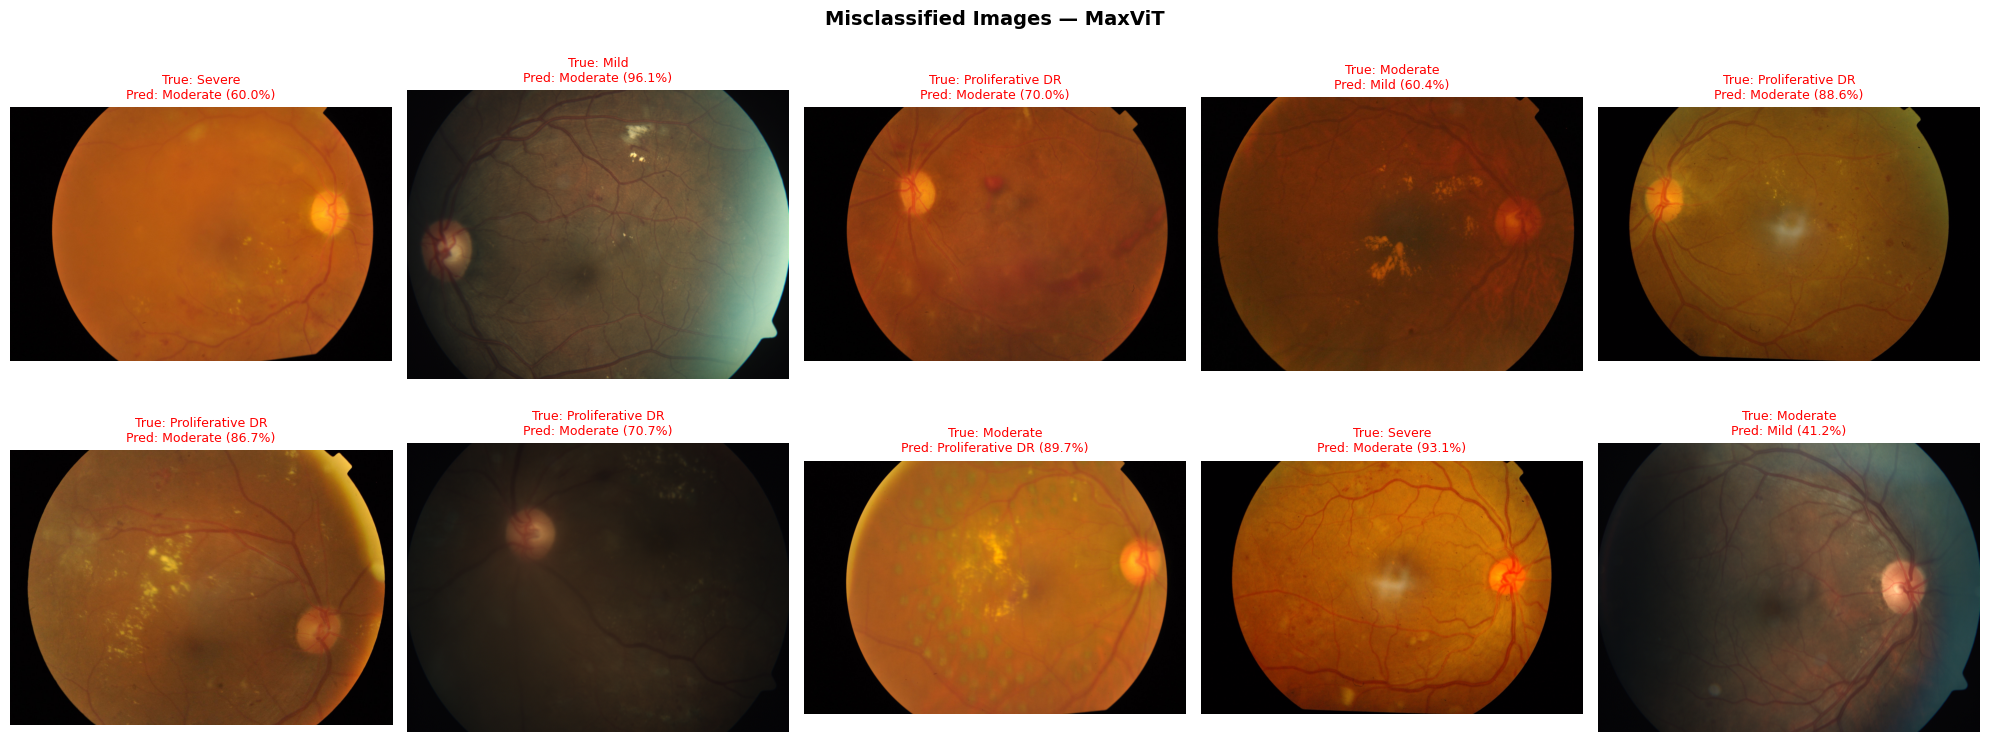

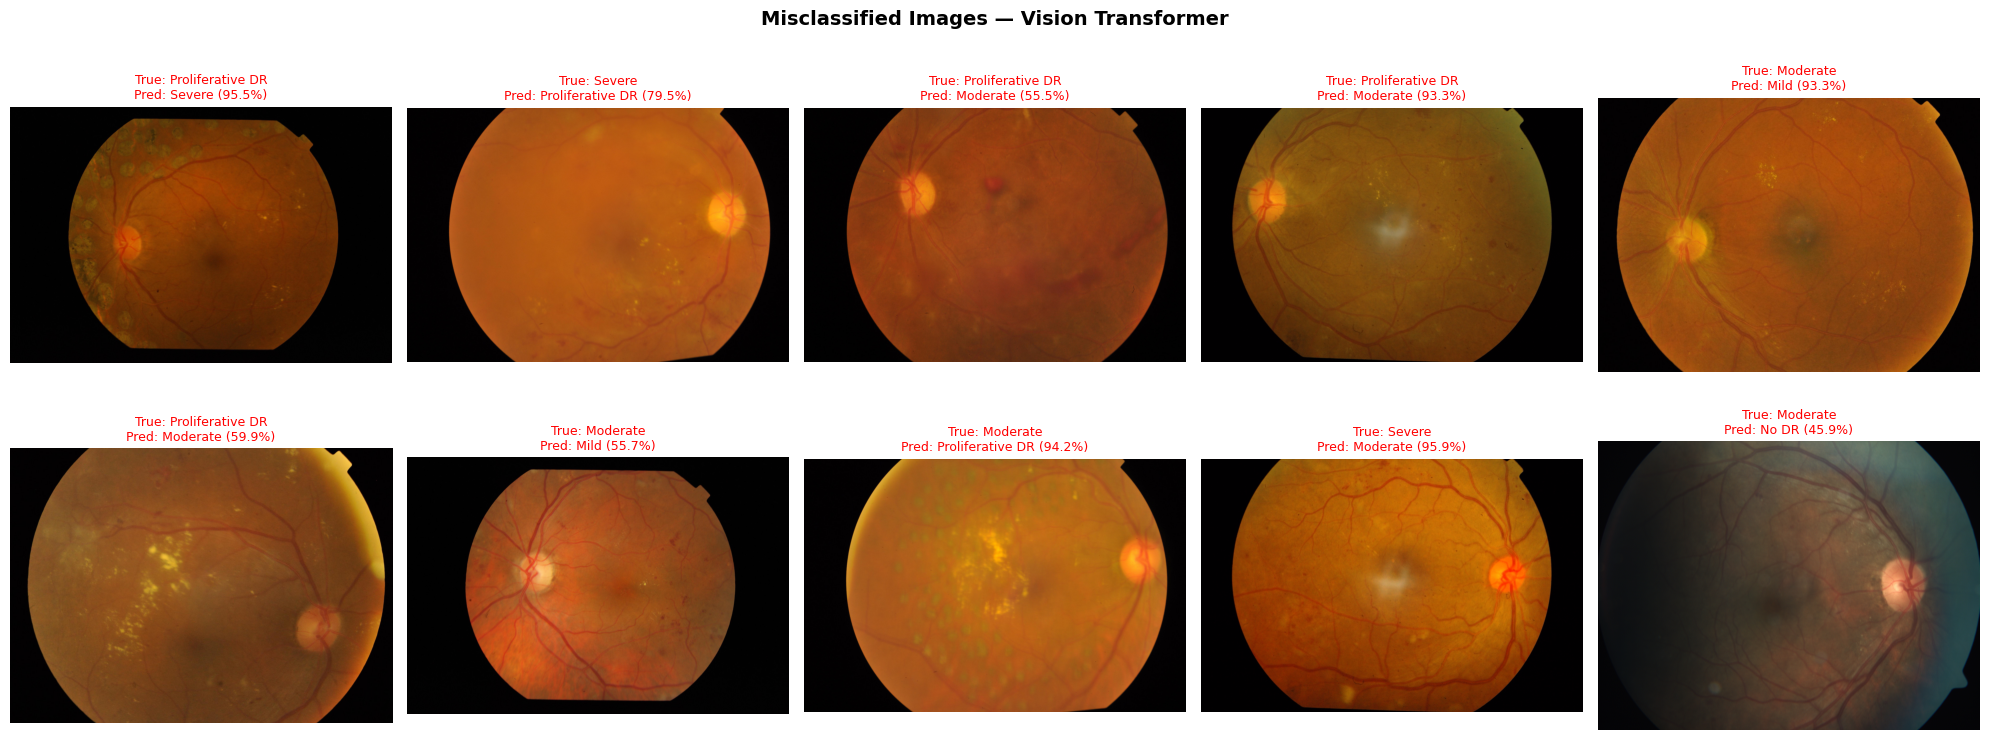

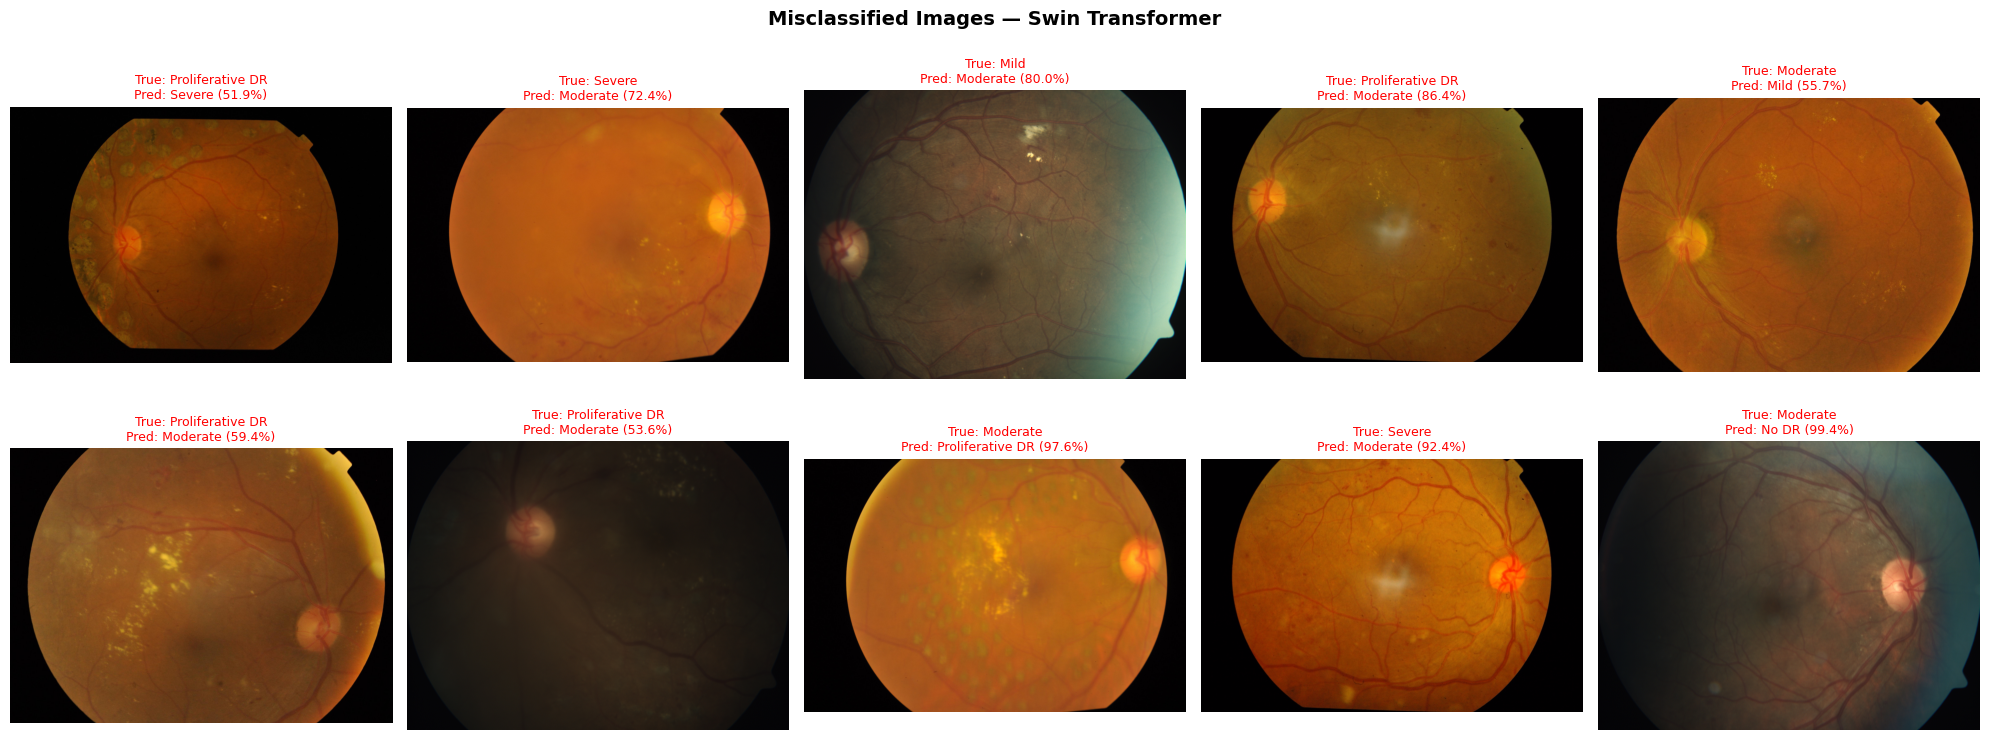

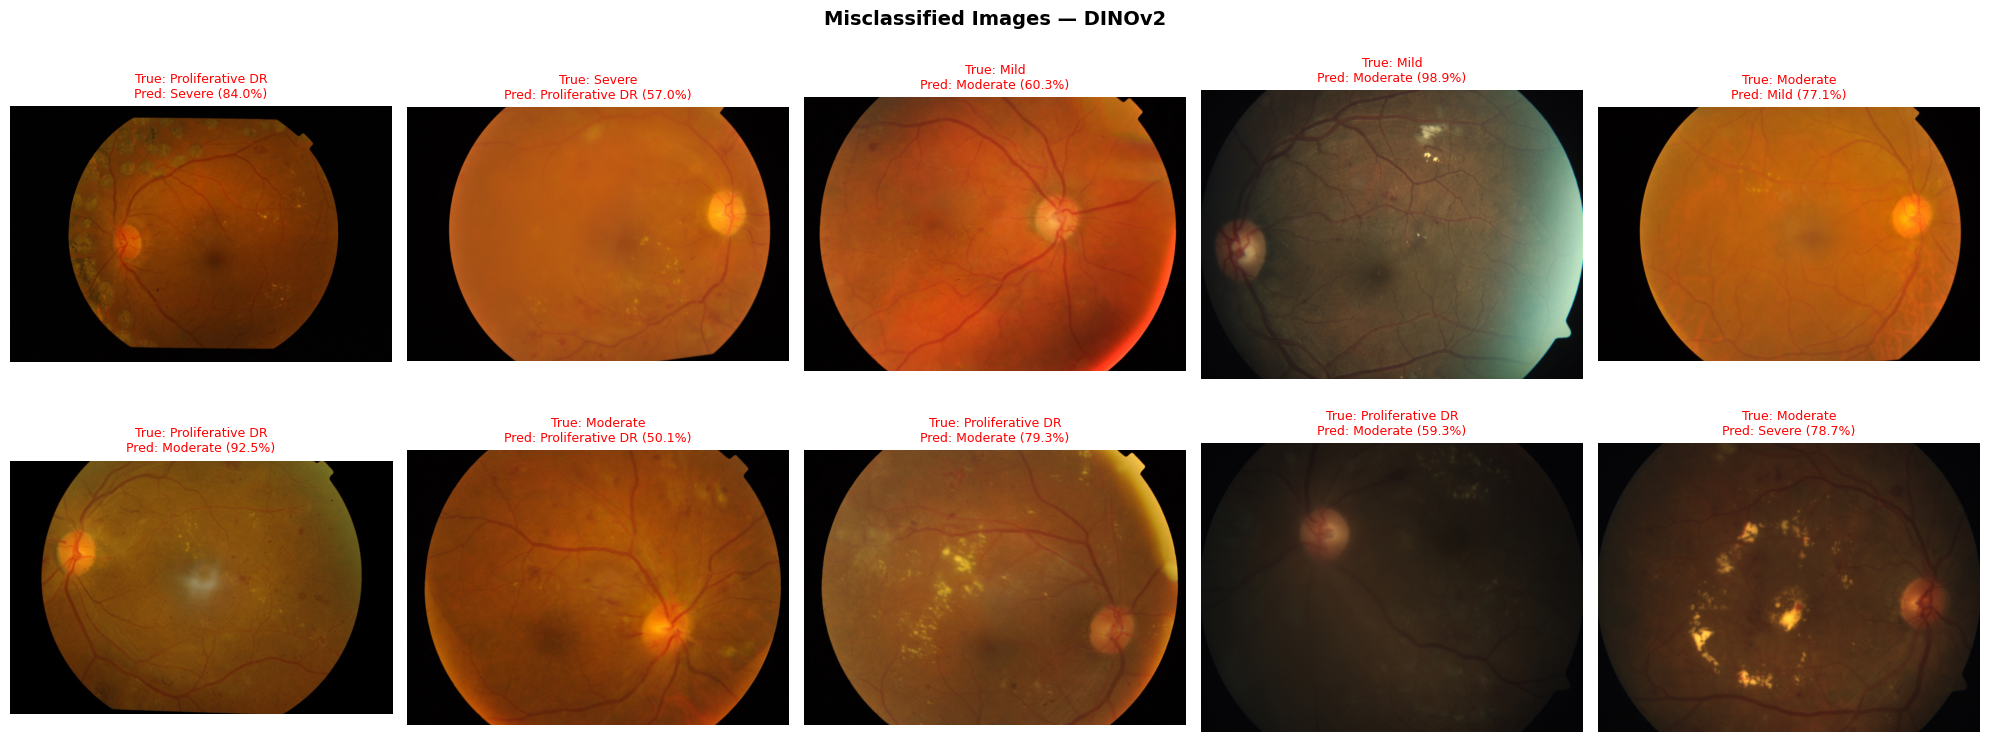

In [59]:
## Section 13 — Misclassified Images
def show_misclassified(model_name: str, y_true, y_pred, y_probs, n: int = 10):
    """Display up to n misclassified test images for the given model."""
    misclassified_idx = np.where(y_true != y_pred)[0]

    if len(misclassified_idx) == 0:
        print(f"{model_name}: no misclassified images found.")
        return

    n_display = min(n, len(misclassified_idx))
    selected_idx = misclassified_idx[:n_display]

    n_cols = 5
    n_rows = int(np.ceil(n_display / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for ax, idx in zip(axes, selected_idx):
        file_path = test_df.iloc[idx]["file_path"]
        image = Image.open(file_path).convert("RGB")

        true_label = CLASS_NAMES[int(y_true[idx])]
        pred_label = CLASS_NAMES[int(y_pred[idx])]
        confidence = float(np.max(y_probs[idx]))

        ax.imshow(image)
        ax.axis("off")
        ax.set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence * 100:.1f}%)",
            color="red", fontsize=9,
        )

    for ax in axes[n_display:]:
        ax.axis("off")

    plt.suptitle(f"Misclassified Images — {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


show_misclassified("MaxViT", y_true, maxvit_pred, maxvit_probs, n=10)
show_misclassified("Vision Transformer", y_true, vit_pred, vit_probs, n=10)
show_misclassified("Swin Transformer", y_true, swin_pred, swin_probs, n=10)
show_misclassified("DINOv2", y_true, dinov2_pred, dinov2_probs, n=10)

In [60]:
## Section 14 — Performance Discussion
# ------------------------------------------------------------------
# Automatically identify the best model per key metric
# ------------------------------------------------------------------
key_metrics = ["Accuracy", "QWK", "F1 Score", "Balanced Accuracy", "MCC"]
best_per_metric = {metric: comparison_df[metric].idxmax() for metric in key_metrics}

print("Best-performing model per metric:")
for metric, model_name in best_per_metric.items():
    value = comparison_df.loc[model_name, metric]
    print(f"  {metric:<20}: {model_name} ({value:.4f})")

overall_best = comparison_df[key_metrics].rank(ascending=False).sum(axis=1).idxmin()
print(f"\nOverall best model (lowest summed rank across key metrics): {overall_best}")


Best-performing model per metric:
  Accuracy            : MaxViT (0.8579)
  QWK                 : Vision Transformer (0.9224)
  F1 Score            : Swin Transformer (0.8510)
  Balanced Accuracy   : Swin Transformer (0.6645)
  MCC                 : MaxViT (0.7755)

Overall best model (lowest summed rank across key metrics): Swin Transformer


In [61]:
# ------------------------------------------------------------------
# Discussion (auto-populated from the metrics computed above)
# ------------------------------------------------------------------
maxvit_acc = comparison_df.loc["MaxViT", "Accuracy"]
vit_acc = comparison_df.loc["Vision Transformer", "Accuracy"]
swin_acc = comparison_df.loc["Swin Transformer", "Accuracy"]

maxvit_qwk = comparison_df.loc["MaxViT", "QWK"]
vit_qwk = comparison_df.loc["Vision Transformer", "QWK"]
swin_qwk = comparison_df.loc["Swin Transformer", "QWK"]

dinov2_acc = comparison_df.loc["DINOv2", "Accuracy"]
dinov2_qwk = comparison_df.loc["DINOv2", "QWK"]

print("DISCUSSION")
print("=" * 60)
print(f"""
MaxViT (Hybrid CNN-Transformer)
  Accuracy: {maxvit_acc:.4f} | QWK: {maxvit_qwk:.4f}
  Strength : combines MBConv (convolutional) blocks with block and grid
             self-attention, giving it convolutional locality for
             texture-heavy pathologies (microaneurysms, hemorrhages,
             exudates) while still modeling longer-range spatial
             relationships across the fundus image.
  Weakness : more architecturally complex than a pure CNN or a pure
             transformer, with more hyperparameters (window/grid sizes)
             that can require careful tuning to fully realize its
             hybrid advantage on a comparatively small medical dataset.

Vision Transformer (ViT-Base/16)
  Accuracy: {vit_acc:.4f} | QWK: {vit_qwk:.4f}
  Strength : global self-attention from the first layer lets the model
             relate lesions anywhere in the image, which can help with
             holistic severity assessment.
  Weakness : lacks a built-in spatial inductive bias, so it typically
             needs more data / stronger augmentation to match CNN
             performance on small-to-medium medical imaging datasets.

Swin Transformer (Swin-Base)
  Accuracy: {swin_acc:.4f} | QWK: {swin_qwk:.4f}
  Strength : hierarchical, shifted-window attention re-introduces
             locality and multi-scale feature maps, combining CNN-like
             inductive bias with transformer representational power.
  Weakness : 
""")

DISCUSSION

MaxViT (Hybrid CNN-Transformer)
  Accuracy: 0.8579 | QWK: 0.9196
  Strength : combines MBConv (convolutional) blocks with block and grid
             self-attention, giving it convolutional locality for
             texture-heavy pathologies (microaneurysms, hemorrhages,
             exudates) while still modeling longer-range spatial
             relationships across the fundus image.
  Weakness : more architecturally complex than a pure CNN or a pure
             transformer, with more hyperparameters (window/grid sizes)
             that can require careful tuning to fully realize its
             hybrid advantage on a comparatively small medical dataset.

Vision Transformer (ViT-Base/16)
  Accuracy: 0.8497 | QWK: 0.9224
  Strength : global self-attention from the first layer lets the model
             relate lesions anywhere in the image, which can help with
             holistic severity assessment.
  Weakness : lacks a built-in spatial inductive bias, so it typically

In [62]:
## Section 15 — Conclusion
print("CONCLUSION")
print("=" * 60)
print(f"""
Across {len(comparison_df)} architectures evaluated on the identical
APTOS 2019 test set, {overall_best} achieved the strongest overall
ranking across accuracy, QWK, F1, balanced accuracy, and MCC.

Transformer-based models (ViT, Swin, DINOv2) {"outperformed" if comparison_df.loc[["Vision Transformer","Swin Transformer","DINOv2"], "QWK"].max() > maxvit_qwk else "did not clearly outperform"} \\
relevant metric for ordinal DR severity grading, in this comparison.

These results matter for AI-assisted diabetic retinopathy diagnosis
because they quantify the real trade-off clinics face when choosing a
screening model: raw predictive performance versus computational cost,
deployment latency, and interpretability. A higher-QWK model reduces
the clinical risk of severity-grade confusion, but must be weighed
against the hardware and latency budget of the deployment setting
(e.g., a rural screening van with limited compute versus a hospital
reading center).

Next steps: model performance alone does not establish clinical trust.
Explainable AI techniques — Grad-CAM-style techniques adapted for MaxViT's
hybrid conv/attention stages and attention-rollout visualization for
ViT/Swin — will be performed in the next notebook to verify that each
model's predictions are grounded in clinically plausible retinal regions
(microaneurysms, hemorrhages, exudates, neovascularization) rather than
spurious correlations.
""")

CONCLUSION

Across 4 architectures evaluated on the identical
APTOS 2019 test set, Swin Transformer achieved the strongest overall
ranking across accuracy, QWK, F1, balanced accuracy, and MCC.

Transformer-based models (ViT, Swin, DINOv2) outperformed \
relevant metric for ordinal DR severity grading, in this comparison.

These results matter for AI-assisted diabetic retinopathy diagnosis
because they quantify the real trade-off clinics face when choosing a
screening model: raw predictive performance versus computational cost,
deployment latency, and interpretability. A higher-QWK model reduces
the clinical risk of severity-grade confusion, but must be weighed
against the hardware and latency budget of the deployment setting
(e.g., a rural screening van with limited compute versus a hospital
reading center).

Next steps: model performance alone does not establish clinical trust.
Explainable AI techniques — Grad-CAM-style techniques adapted for MaxViT's
hybrid conv/attention stages and 

In [65]:
print("Ground truth distribution:")
print(np.bincount(y_true))

print("\nMaxViT prediction distribution:")
print(np.bincount(maxvit_pred))

print("\nFirst 20 predictions:")
print(maxvit_pred[:20])

print("\nFirst 20 labels:")
print(y_true[:20])

Ground truth distribution:
[199  30  87  17  33]

MaxViT prediction distribution:
[199  21 115  10  21]

First 20 predictions:
[0 2 4 0 0 0 2 2 1 2 0 0 2 0 2 0 0 0 0 2]

First 20 labels:
[0 2 4 0 0 0 3 2 1 1 0 0 2 0 2 0 0 0 0 4]
